In [1]:
import pandas as pd
import numpy as np
import matplotlib.pyplot as plt
import seaborn as sns

In [3]:
df = pd.read_csv("Titanic-Dataset.csv")

In [4]:
df.head()

,PassengerId,Survived,Pclass,Name,Sex,Age,SibSp,Parch,Ticket,Fare,Cabin,Embarked
0,1,0,3,"Braund, Mr. Owen Harris",male,22.0,1,0,A/5 21171,7.2500,NaN,S
1,2,1,1,"Cumings, Mrs. John Bradley (Florence Briggs Th...",female,38.0,1,0,PC 17599,71.2833,C85,C
2,3,1,3,"Heikkinen, Miss. Laina",female,26.0,0,0,STON/O2. 3101282,7.9250,NaN,S
3,4,1,1,"Futrelle, Mrs. Jacques Heath (Lily May Peel)",female,35.0,1,0,113803,53.1000,C123,S
4,5,0,3,"Allen, Mr. William Henry",male,35.0,0,0,373450,8.0500,NaN,S


In [5]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 891 entries, 0 to 890
Data columns (total 12 columns):
 #   Column       Non-Null Count  Dtype  
---  ------       --------------  -----  
 0   PassengerId  891 non-null    int64  
 1   Survived     891 non-null    int64  
 2   Pclass       891 non-null    int64  
 3   Name         891 non-null    object 
 4   Sex          891 non-null    object 
 5   Age          714 non-null    float64
 6   SibSp        891 non-null    int64  
 7   Parch        891 non-null    int64  
 8   Ticket       891 non-null    object 
 9   Fare         891 non-null    float64
 10  Cabin        204 non-null    object 
 11  Embarked     889 non-null    object 
dtypes: float64(2), int64(5), object(5)
memory usage: 83.7+ KB


In [6]:
df.isnull().sum()

PassengerId      0
Survived         0
Pclass           0
Name             0
Sex              0
Age            177
SibSp            0
Parch            0
Ticket           0
Fare             0
Cabin          687
Embarked         2
dtype: int64

In [8]:
df['Age'] = df['Age'].fillna(df['Age'].mean())

In [9]:
df['Embarked'] = df['Embarked'].fillna(df['Embarked'].mode()[0])

In [10]:
df.drop('Cabin', axis=1, inplace=True)

In [11]:
df.isnull().sum()

PassengerId    0
Survived       0
Pclass         0
Name           0
Sex            0
Age            0
SibSp          0
Parch          0
Ticket         0
Fare           0
Embarked       0
dtype: int64

In [12]:
bins = [0,12,19,35,60,100]

labels = ['Child',
          'Teen',
          'Young Adult',
          'Adult',
          'Senior']

df['AgeGroup'] = pd.cut(
    df['Age'],
    bins=bins,
    labels=labels
)

In [13]:
df[['Age','AgeGroup']].head()

,Age,AgeGroup
0,22.0,Young Adult
1,38.0,Adult
2,26.0,Young Adult
3,35.0,Young Adult
4,35.0,Young Adult


In [24]:
age_survival = df.groupby('AgeGroup', observed=False)['Survived'].mean()

print(age_survival)

AgeGroup
Child          0.579710
Teen           0.410526
Young Adult    0.352941
Adult          0.400000
Senior         0.227273
Name: Survived, dtype: float64


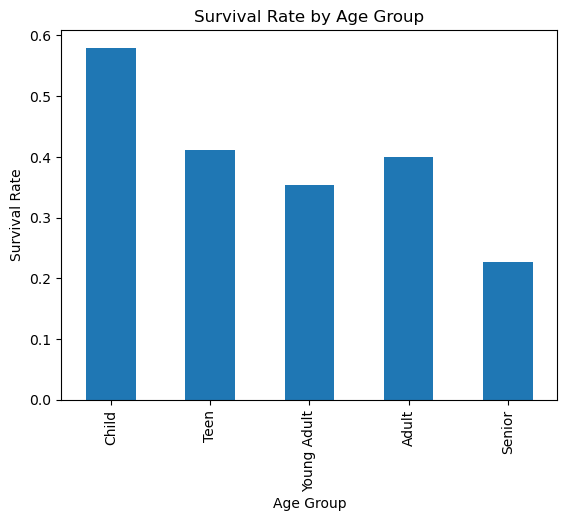

In [15]:
age_survival.plot(kind='bar')

plt.title("Survival Rate by Age Group")

plt.xlabel("Age Group")

plt.ylabel("Survival Rate")

plt.show()

In [16]:
embark_survival = df.groupby('Embarked')['Survived'].mean()

print(embark_survival)

Embarked
C    0.553571
Q    0.389610
S    0.339009
Name: Survived, dtype: float64


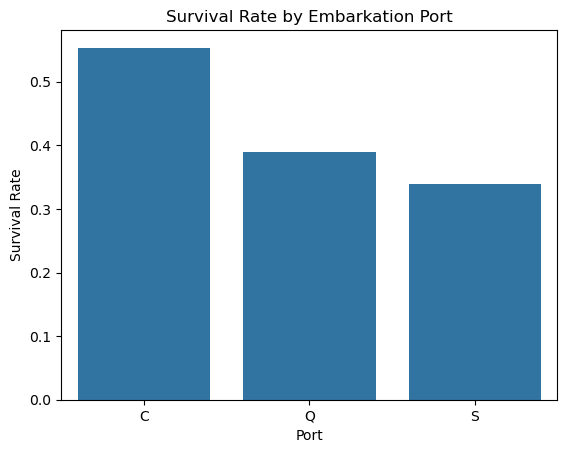

In [17]:
sns.barplot(
    x=embark_survival.index,
    y=embark_survival.values
)

plt.title("Survival Rate by Embarkation Port")

plt.xlabel("Port")

plt.ylabel("Survival Rate")

plt.show()

In [18]:
df['FamilySize'] = df['SibSp'] + df['Parch']

In [19]:
df[['SibSp','Parch','FamilySize']].head()

,SibSp,Parch,FamilySize
0,1,0,1
1,1,0,1
2,0,0,0
3,1,0,1
4,0,0,0


In [20]:
family_survival = df.groupby('FamilySize')['Survived'].mean()

print(family_survival)

FamilySize
0     0.303538
1     0.552795
2     0.578431
3     0.724138
4     0.200000
5     0.136364
6     0.333333
7     0.000000
10    0.000000
Name: Survived, dtype: float64


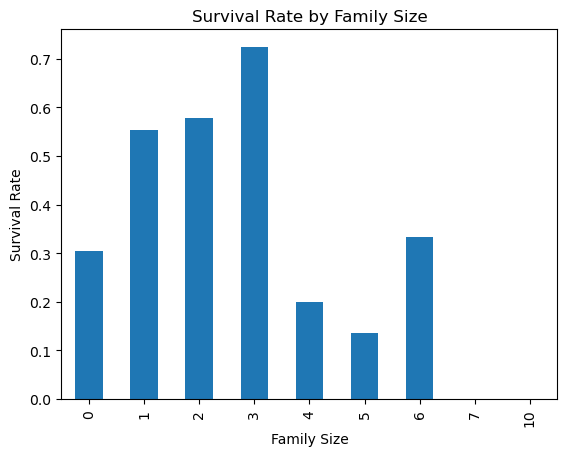

In [21]:
family_survival.plot(kind='bar')

plt.title("Survival Rate by Family Size")

plt.xlabel("Family Size")

plt.ylabel("Survival Rate")

plt.show()

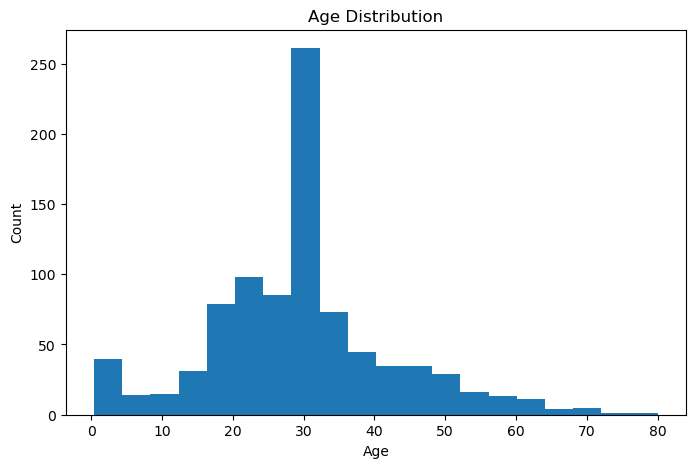

In [22]:
plt.figure(figsize=(8,5))

plt.hist(df['Age'], bins=20)

plt.title("Age Distribution")

plt.xlabel("Age")

plt.ylabel("Count")

plt.show()

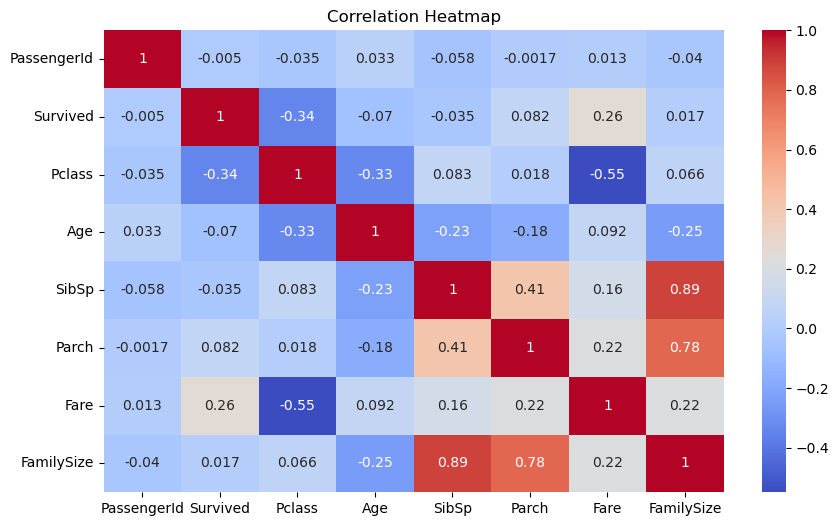

In [23]:
plt.figure(figsize=(10,6))

sns.heatmap(
    df.corr(numeric_only=True),
    annot=True,
    cmap='coolwarm'
)

plt.title("Correlation Heatmap")

plt.show()

In [ ]:
INSIGHTS

1. Children had better survival chances.

2. Survival rate varies across embarkation ports.

3. Medium-sized families had better survival rates.

4. Females survived more than males.

5. Passenger class influenced survival.